In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

## **Pemuatan dataset**

Selanjutnya, Google Drive dihubungkan ke Google Colab untuk membaca dan memuat dataset CSV mentah ke dalam dataframe menggunakan pandas, dilengkapi dengan penanganan error untuk memastikan file berhasil diakses.

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path file CSV
file_path = '/content/drive/My Drive/PBA/rawdata.csv'

try:
    df_agodarev = pd.read_csv(file_path)
    print(f'Successfully loaded CSV from "{file_path}"')
    display(df_agodarev.head())

except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
    df_agodarev = pd.DataFrame()

except pd.errors.ParserError:
    print("Error: Could not parse the CSV file.")
    df_agodarev = pd.DataFrame()

except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_agodarev = pd.DataFrame()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded CSV from "/content/drive/My Drive/PBA/rawdata.csv"


/tmp/ipykernel_518/1362158745.py:11: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_agodarev = pd.read_csv(file_path)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,de242464-90f8-4322-ab6f-7ed2194c969c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any incon...",2026-03-02 08:19:42,14.6.0
1,5a0fc31e-353a-48dd-a505-ee6e48738474,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,it's a great and very useful app honestly it o...,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience...,2026-03-02 05:07:34,14.6.0
2,2926363b-e0fc-4115-9585-67b931f6372c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Super good price!,5,0,14.6.0,2026-03-02 02:57:39,Thank you for sharing your positive experience...,2026-03-02 03:07:34,14.6.0
3,ac366bdb-052b-4eeb-917e-7662ebab3182,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Dear Sir/Madam, I made a booking yesterday at ...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the i...",2026-03-02 02:37:45,NaN
4,d008c6b3-a2e8-4f79-86a3-cb942622e6d8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,great help for booking room,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience...,2026-03-02 00:07:34,NaN


## **Menampilkan Ringkasan Data**

Pemanggilan variabel df_agodarev dilakukan untuk menampilkan pratinjau tabel dataset secara langsung guna memverifikasi struktur baris dan kolom yang telah dimuat.

In [ ]:
df_agodarev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,de242464-90f8-4322-ab6f-7ed2194c969c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any incon...",2026-03-02 08:19:42,14.6.0
1,5a0fc31e-353a-48dd-a505-ee6e48738474,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,it's a great and very useful app honestly it o...,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience...,2026-03-02 05:07:34,14.6.0
2,2926363b-e0fc-4115-9585-67b931f6372c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Super good price!,5,0,14.6.0,2026-03-02 02:57:39,Thank you for sharing your positive experience...,2026-03-02 03:07:34,14.6.0
3,ac366bdb-052b-4eeb-917e-7662ebab3182,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Dear Sir/Madam, I made a booking yesterday at ...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the i...",2026-03-02 02:37:45,NaN
4,d008c6b3-a2e8-4f79-86a3-cb942622e6d8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,great help for booking room,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience...,2026-03-02 00:07:34,NaN
...,...,...,...,...,...,...,...,...,...,...,...
132870,3be631a1-2c8a-441b-b911-d8ed0e88e126,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Nicely done hotel booking app with some good r...,5,2,1.0,2011-08-08 19:32:32,NaN,NaN,1.0
132871,045a071c-5dfc-4a64-9157-a52a4193af1b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,5* not bad,5,0,1.0,2011-08-06 10:08:28,NaN,NaN,1.0
132872,e8b28b7a-bf23-4d0d-86a0-115ecb2385b1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Installed this last weekend (I was in Hua Hin,...",5,2,1.0,2011-08-04 04:09:01,NaN,NaN,1.0
132873,2ff4ffff-d47c-4397-bec1-ca7254b4134f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Can't search by hotel name (eg if u know the n...,1,1,1.0,2011-08-02 01:08:38,NaN,NaN,1.0


## **Pemeriksaan Struktur Dataset**

Pemanggilan fungsi info() dilakukan untuk melihat ringkasan struktur dataframe, mengetahui tipe data pada setiap kolom, serta mendeteksi keberadaan nilai kosong (missing values).

In [ ]:
df_agodarev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132875 entries, 0 to 132874
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              132875 non-null  object
 1   userName              132875 non-null  object
 2   userImage             132875 non-null  object
 3   content               132754 non-null  object
 4   score                 132875 non-null  int64 
 5   thumbsUpCount         132875 non-null  int64 
 6   reviewCreatedVersion  118498 non-null  object
 7   at                    132875 non-null  object
 8   replyContent          55057 non-null   object
 9   repliedAt             55057 non-null   object
 10  appVersion            118498 non-null  object
dtypes: int64(2), object(9)
memory usage: 11.2+ MB


## **Inisialisasi Stopwords dan Penggabungan Teks**

Pustaka yang dibutuhkan diimpor untuk pemrosesan teks dan visualisasi. Stopwords bawaan bahasa Inggris diinisialisasi melalui nltk, kemudian seluruh baris teks pada kolom ulasan digabungkan menjadi satu kesatuan string setelah mengabaikan data yang bernilai kosong.

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download English stopwords if not available
nltk.download('stopwords')
english_stopwords = set(stopwords.words('english'))

# Assuming the text column is named 'content', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_agodarev[text_column].dropna().astype(str))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Seleksi Kolom yang Relevan**

Kolom yang bersifat personal atau tidak dibutuhkan dalam analisis, seperti ID dan profil pengguna, diabaikan. Hanya fitur-fitur penting seperti isi ulasan, skor, dan atribut pendukung lainnya yang dipertahankan untuk menyederhanakan struktur dataset.

In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_agodarev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any incon...",2026-03-02 08:19:42
1,it's a great and very useful app honestly it o...,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience...,2026-03-02 05:07:34
2,Super good price!,5,0,14.6.0,2026-03-02 02:57:39,Thank you for sharing your positive experience...,2026-03-02 03:07:34
3,"Dear Sir/Madam, I made a booking yesterday at ...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the i...",2026-03-02 02:37:45
4,great help for booking room,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience...,2026-03-02 00:07:34
...,...,...,...,...,...,...,...
132870,Nicely done hotel booking app with some good r...,5,2,1.0,2011-08-08 19:32:32,NaN,NaN
132871,5* not bad,5,0,1.0,2011-08-06 10:08:28,NaN,NaN
132872,"Installed this last weekend (I was in Hua Hin,...",5,2,1.0,2011-08-04 04:09:01,NaN,NaN
132873,Can't search by hotel name (eg if u know the n...,1,1,1.0,2011-08-02 01:08:38,NaN,NaN


##Inisialisasi Stopwords Bahasa Inggris
Pustaka nltk digunakan untuk mengunduh dan memuat daftar kata umum (stopwords) bahasa Inggris ke dalam sistem. Sebagai verifikasi awal, 20 kata pertama dari daftar tersebut ditampilkan untuk memastikan repositori bahasa telah siap digunakan dalam tahap pembersihan teks.

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get English stopwords
english_stopwords = stopwords.words('english')

# Display first 20 stopwords
print(english_stopwords[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Verifikasi Total Stopwords**

Total kata dalam daftar stopwords ditampilkan menggunakan fungsi len() untuk memverifikasi jumlah data yang telah dimuat sebelum digunakan pada tahap pembersihan.

In [ ]:
print(len(english_stopwords))

198


In [ ]:
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

## **Analisis dan Visualisasi Frekuensi Kata**

Seluruh teks ulasan digabungkan dan dilakukan proses tokenisasi untuk menghitung frekuensi kemunculan setiap kata setelah mengeliminasi stopwords bahasa Inggris. Hasil penghitungan tersebut dikonversi ke dalam dataframe dan divisualisasikan menggunakan diagram batang horizontal guna mengidentifikasi kata-kata yang paling dominan dalam dataset.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Word,Frequency
0,good,24949
1,app,22597
2,easy,20077
3,hotel,19091
4,booking,18166
...,...,...
95,tried,1401
96,want,1390
97,would,1385
98,option,1365


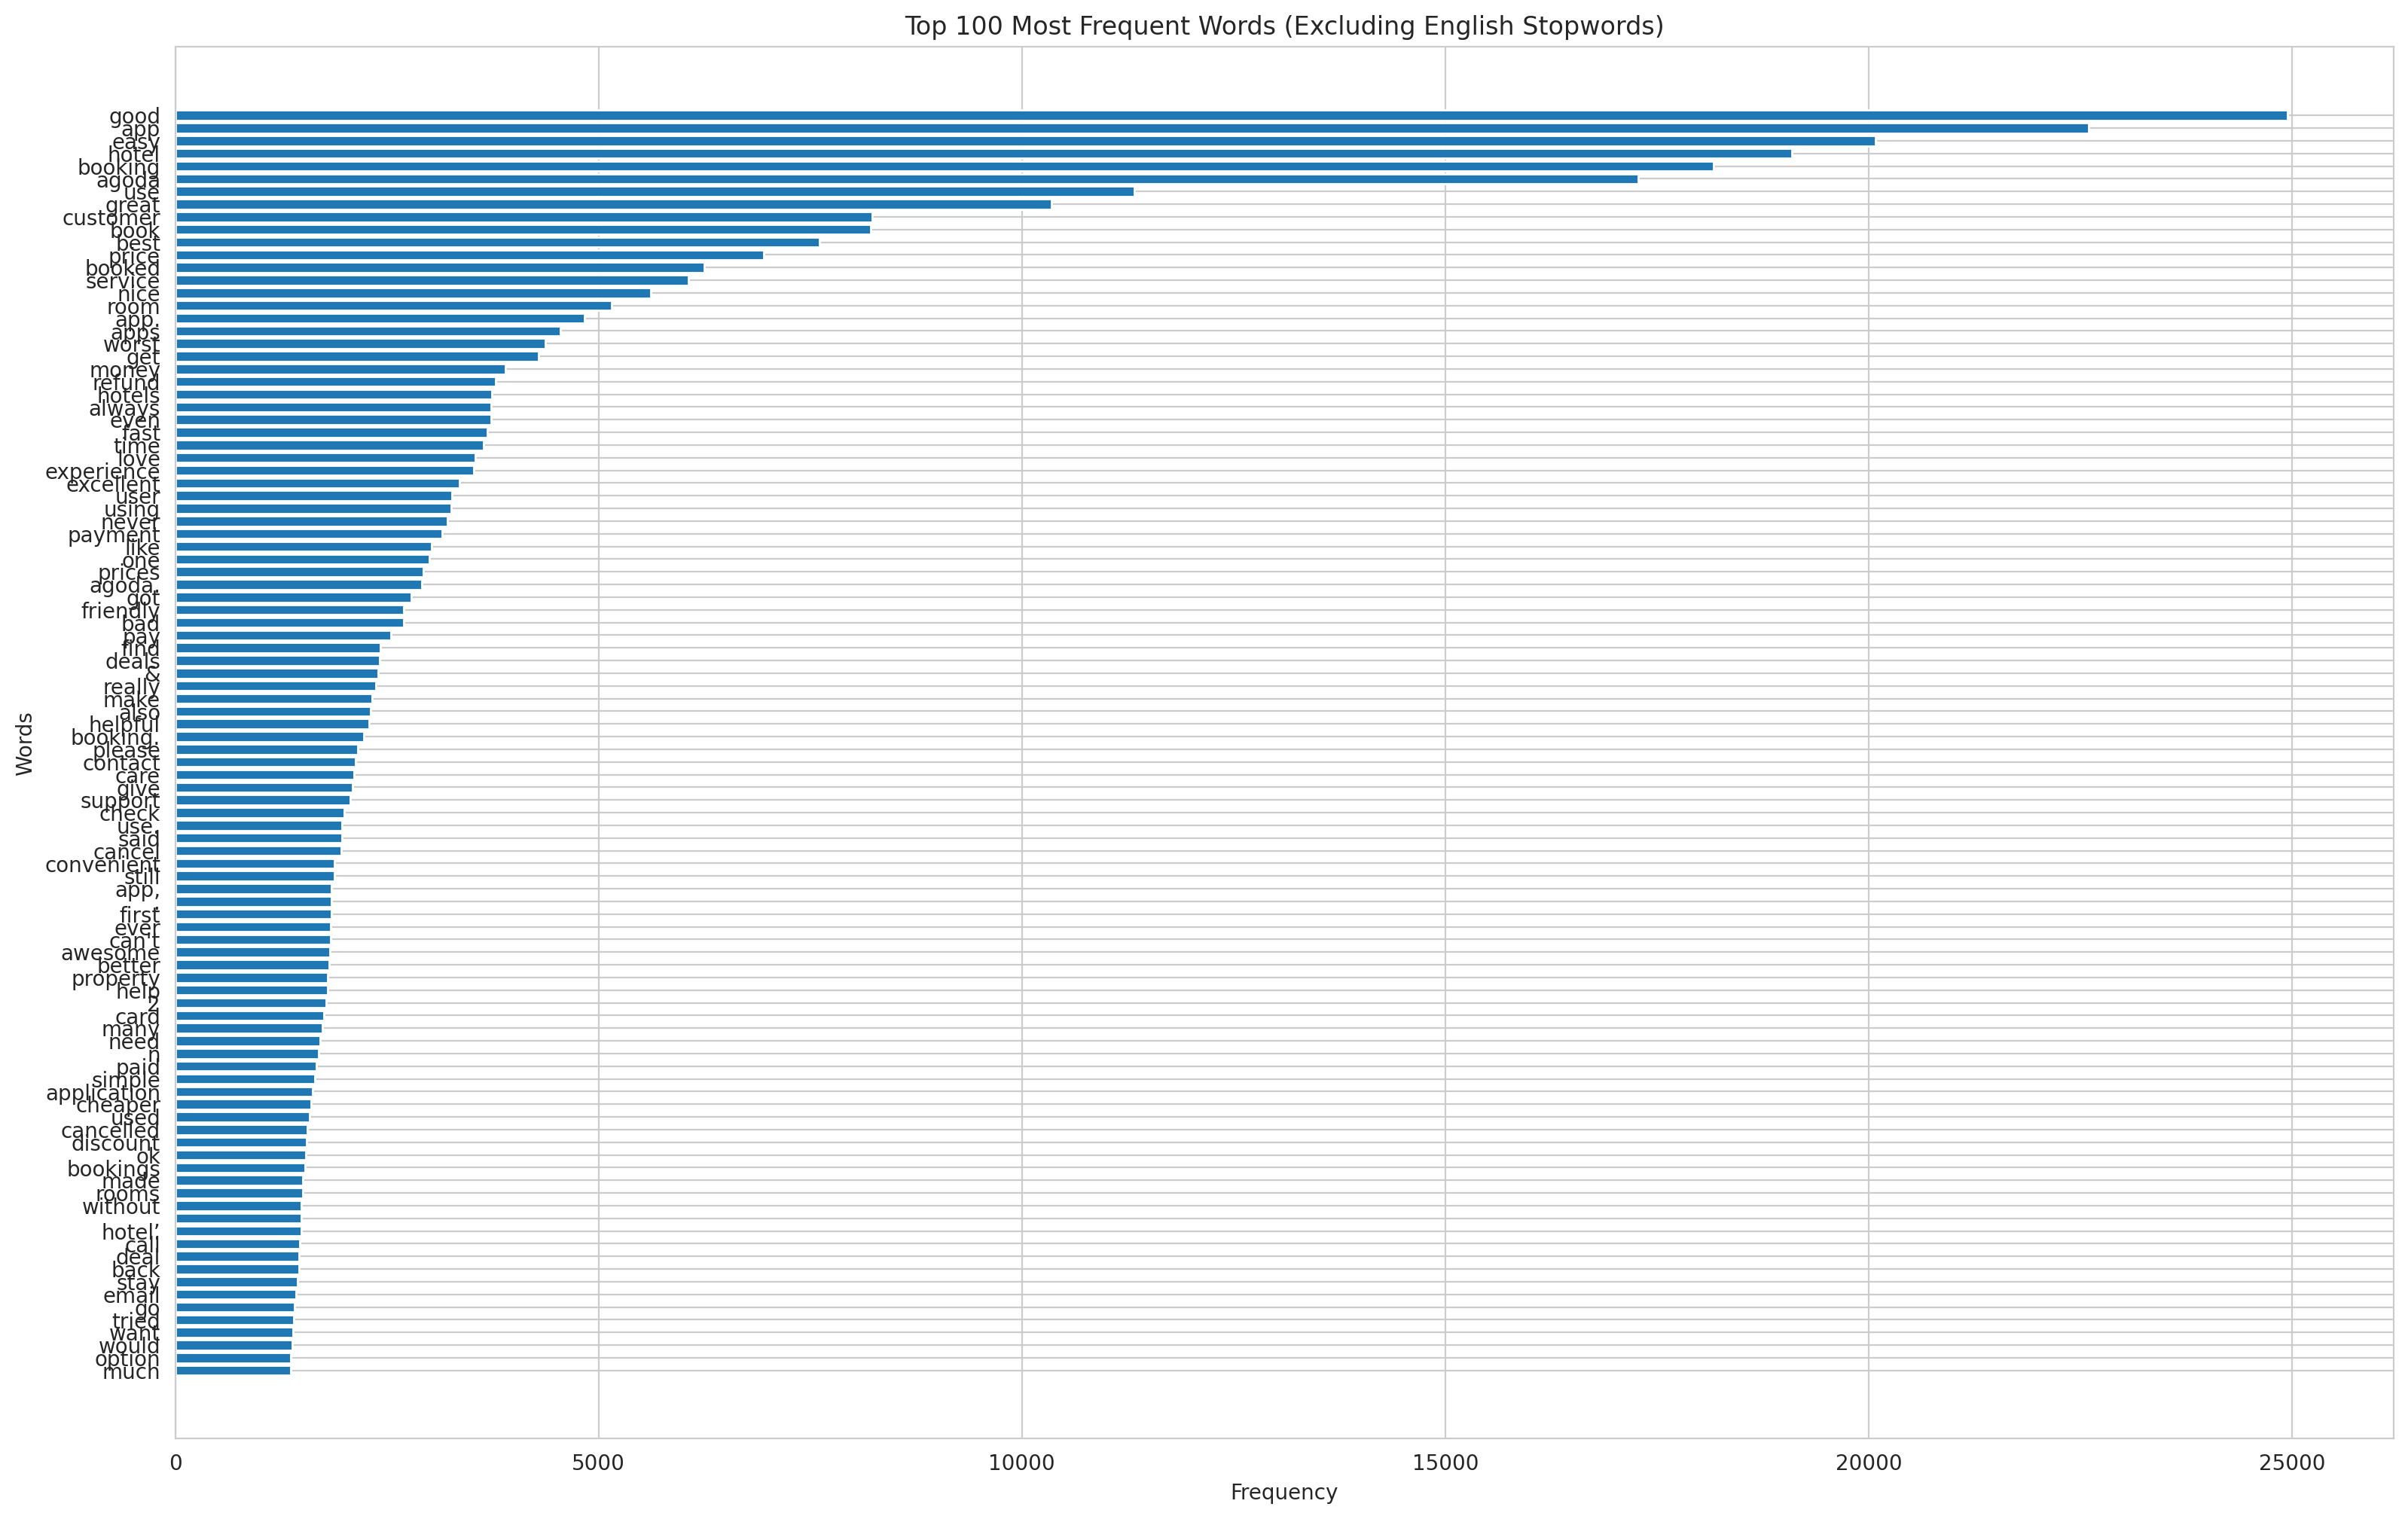

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download stopwords jika belum ada
nltk.download('stopwords')

# Stopwords bahasa Inggris
english_stopwords = set(stopwords.words('english'))

# Assuming the text column is named 'content'
text_column = 'content'

# Combine all text data into one string
all_text = ' '.join(df_agodarev[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in english_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 100 Most Frequent Words (Excluding English Stopwords)")
plt.show()

## **Ekstraksi Kata Paling Dominan**

Variabel common_words dipanggil untuk menampilkan daftar pasangan kata beserta jumlah kemunculannya secara mendetail. Tahap ini bertujuan untuk meninjau efektivitas proses pembersihan kata serta memvalidasi hasil ekstraksi fitur teks sebelum masuk ke tahap pemodelan.

In [ ]:
common_words

[('good', 24949),
 ('app', 22597),
 ('easy', 20077),
 ('hotel', 19091),
 ('booking', 18166),
 ('agoda', 17277),
 ('use', 11330),
 ('great', 10353),
 ('customer', 8232),
 ('book', 8214),
 ('best', 7610),
 ('price', 6955),
 ('booked', 6249),
 ('service', 6064),
 ('nice', 5613),
 ('room', 5156),
 ('app.', 4838),
 ('apps', 4546),
 ('worst', 4371),
 ('get', 4295),
 ('money', 3899),
 ('refund', 3787),
 ('hotels', 3742),
 ('always', 3733),
 ('even', 3732),
 ('fast', 3686),
 ('time', 3639),
 ('love', 3546),
 ('experience', 3526),
 ('excellent', 3358),
 ('user', 3265),
 ('using', 3264),
 ('never', 3215),
 ('payment', 3150),
 ('like', 3024),
 ('one', 3005),
 ('prices', 2928),
 ('agoda.', 2909),
 ('got', 2786),
 ('friendly', 2698),
 ('bad', 2697),
 ('pay', 2546),
 ('find', 2424),
 ('deals', 2418),
 ('&', 2396),
 ('really', 2370),
 ('make', 2323),
 ('also', 2306),
 ('helpful', 2288),
 ('booking.', 2228),
 ('please', 2159),
 ('contact', 2129),
 ('care', 2109),
 ('give', 2096),
 ('support', 2070),
 

Homework: WEEK 3/ 11 maret 2026 (TUGAS 2)

Bisa menambahkan, list kata dari most frequent words, kata2 yg tidak memiliki arti penting (eg ga (no-2), gak-no4) ke list indonesian_stopwords


## **Kustomisasi Daftar Stopwords**

Daftar stopwords bawaan diperluas dengan menambahkan kata-kata khusus domain (domain-specific) yang sering muncul namun tidak memiliki nilai sentimen, seperti nama aplikasi dan istilah teknis platform. Selain itu, kata-kata gangguan (noise) lintas bahasa dan residu tanda baca juga dimasukkan ke dalam daftar custom_stopwords untuk memastikan proses pembersihan teks lebih optimal dan fokus pada kata-kata pembawa emosi.

In [ ]:
import nltk
from nltk.corpus import stopwords

# nltk.download('stopwords')

# Stopwords default English
english_stopwords = set(stopwords.words('english'))

# Tambahan stopwords dari frequent words (Penggabungan Keseluruhan)
custom_stopwords = [
    # 1. Domain-specific terms
    'app', 'hotel', 'booking', 'agoda', 'customer', 'book', 'booked', 'room', 'apps',
    'hotels', 'user', 'payment', 'application', 'property', 'stay', 'bookings', 'option',
    'reservation', 'flight', 'travel', 'place', 'date', 'options', 'company', 'trip',
    'account', 'owner', 'bank', 'phone', 'star', 'system', 'review', 'reviews', 'night',

    # 2. Neutral verbs, Adjectives, & Actions
    'use', 'get', 'using', 'pay', 'find', 'make', 'check', 'said', 'used', 'made',
    'call', 'email', 'go', 'tried', 'way', 'another', 'try', 'show', 'take', 'know', 'different',
    'told', 'received', 'change', 'see', 'provide', 'found', 'reached', 'able', 'keep',
    'called', 'due', 'showing', 'done', 'confirmed', 'every', 'say', 'asked', 'saying',
    'went', 'shows', 'reach', 'work', 'says', 'trying', 'getting', 'going', 'ask', 'new',
    'making', 'given', 'update', 'took', 'shown', 'gave', 'works',

    # 3. General English words, Time, & Quantity
    'always', 'even', 'time', 'one', 'got', 'also', 'please', 'still', 'first', 'ever',
    'many', 'need', 'much', 'want', 'would', 'back', 'give', 'last', 'already', 'days',
    'times', 'lot', 'full', 'far', 'could', 'since', 'well', 'via', 'day', 'hours', 'later',
    'everything', 'totally', 'two', 'anything',

    # 4. Pronouns & Neutral Slang
    'u', 'us', 'people',

    # 5. System / Platform Terms
    'site', 'website', 'number', 'amount', 'details', 'online', 'information', 'mobile',

    # 6. Cross-lingual / Indonesian Noise
    'dan', 'di', 'saya', 'tidak', 'aplikasi', 'yang', 'yg', 'sangat', 'ada', 'sudah',

    # 7. Symbols, Numbers, & Punctuation Residue
    '&', '.', ' ', ',', '-', '!', '1', '2', '3', '4', '5', 'n',
    'app.', 'agoda.', 'booking.', 'hotel.', 'use.', 'app,', 'it.', 'service.', 'agoda,', 'hotel,',
    'apps.', 'experience.', 'booking,', 'refund.', 'use,', 'app!', 'price.', 'money.', 'hotels.',
    'me.', 'again.', 'room.', 'good.', 'time.', '..'
]

# Gabungkan dengan stopwords bawaan
english_stopwords.update(custom_stopwords)

print("Total stopwords saat ini:", len(english_stopwords))

Total stopwords saat ini: 381


In [ ]:
english_stopwords

{' ',
 '!',
 '&',
 ',',
 '-',
 '.',
 '..',
 '1',
 '2',
 '3',
 '4',
 '5',
 'a',
 'able',
 'about',
 'above',
 'account',
 'ada',
 'after',
 'again',
 'again.',
 'against',
 'agoda',
 'agoda,',
 'agoda.',
 'ain',
 'all',
 'already',
 'also',
 'always',
 'am',
 'amount',
 'an',
 'and',
 'another',
 'any',
 'anything',
 'aplikasi',
 'app',
 'app!',
 'app,',
 'app.',
 'application',
 'apps',
 'apps.',
 'are',
 'aren',
 "aren't",
 'as',
 'ask',
 'asked',
 'at',
 'back',
 'bank',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'book',
 'booked',
 'booking',
 'booking,',
 'booking.',
 'bookings',
 'both',
 'but',
 'by',
 'call',
 'called',
 'can',
 'change',
 'check',
 'company',
 'confirmed',
 'could',
 'couldn',
 "couldn't",
 'customer',
 'd',
 'dan',
 'date',
 'day',
 'days',
 'details',
 'di',
 'did',
 'didn',
 "didn't",
 'different',
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'done',
 'down',
 'due',
 'during',
 'each',
 'email',
 'even',
 '

## **Analisis Frekuensi Kata Pasca-Pembersihan**

Proses tokenisasi dan penghitungan frekuensi dilakukan kembali menggunakan daftar stopwords yang telah dikustomisasi. Hasil akhirnya ditampilkan dalam bentuk tabel dan diagram batang horizontal untuk memverifikasi bahwa noise telah berkurang secara signifikan, sehingga menyisakan kata-kata yang lebih relevan untuk analisis topik dan sentimen.

[('good', 24949), ('easy', 20077), ('great', 10353), ('best', 7610), ('price', 6955), ('service', 6064), ('nice', 5613), ('worst', 4371), ('money', 3899), ('refund', 3787), ('fast', 3686), ('love', 3546), ('experience', 3526), ('excellent', 3358), ('never', 3215), ('like', 3024), ('prices', 2928), ('friendly', 2698), ('bad', 2697), ('deals', 2418), ('really', 2370), ('helpful', 2288), ('contact', 2129), ('care', 2109), ('support', 2070), ('cancel', 1963), ('convenient', 1883), ("can't", 1836), ('awesome', 1824), ('better', 1819), ('help', 1804), ('card', 1752), ('paid', 1668), ('simple', 1654), ('cheaper', 1604), ('cancelled', 1565), ('discount', 1549), ('ok', 1546), ('rooms', 1508), ('without', 1492), ('deal', 1467), ('confirmation', 1303), ('thanks', 1302), ('cheap', 1268), ('thank', 1265), ('quick', 1237), ('rate', 1220), ('useful', 1204), ('rates', 1182), ('fraud', 1159), ('available', 1148), ('fake', 1111), ('search', 1110), ('credit', 1100), ('cannot', 1085), ('charged', 1073), (

,Word,Frequency
0,good,24949
1,easy,20077
2,great,10353
3,best,7610
4,price,6955
...,...,...
95,staff,530
96,happy,520
97,lowest,514
98,wait,504


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


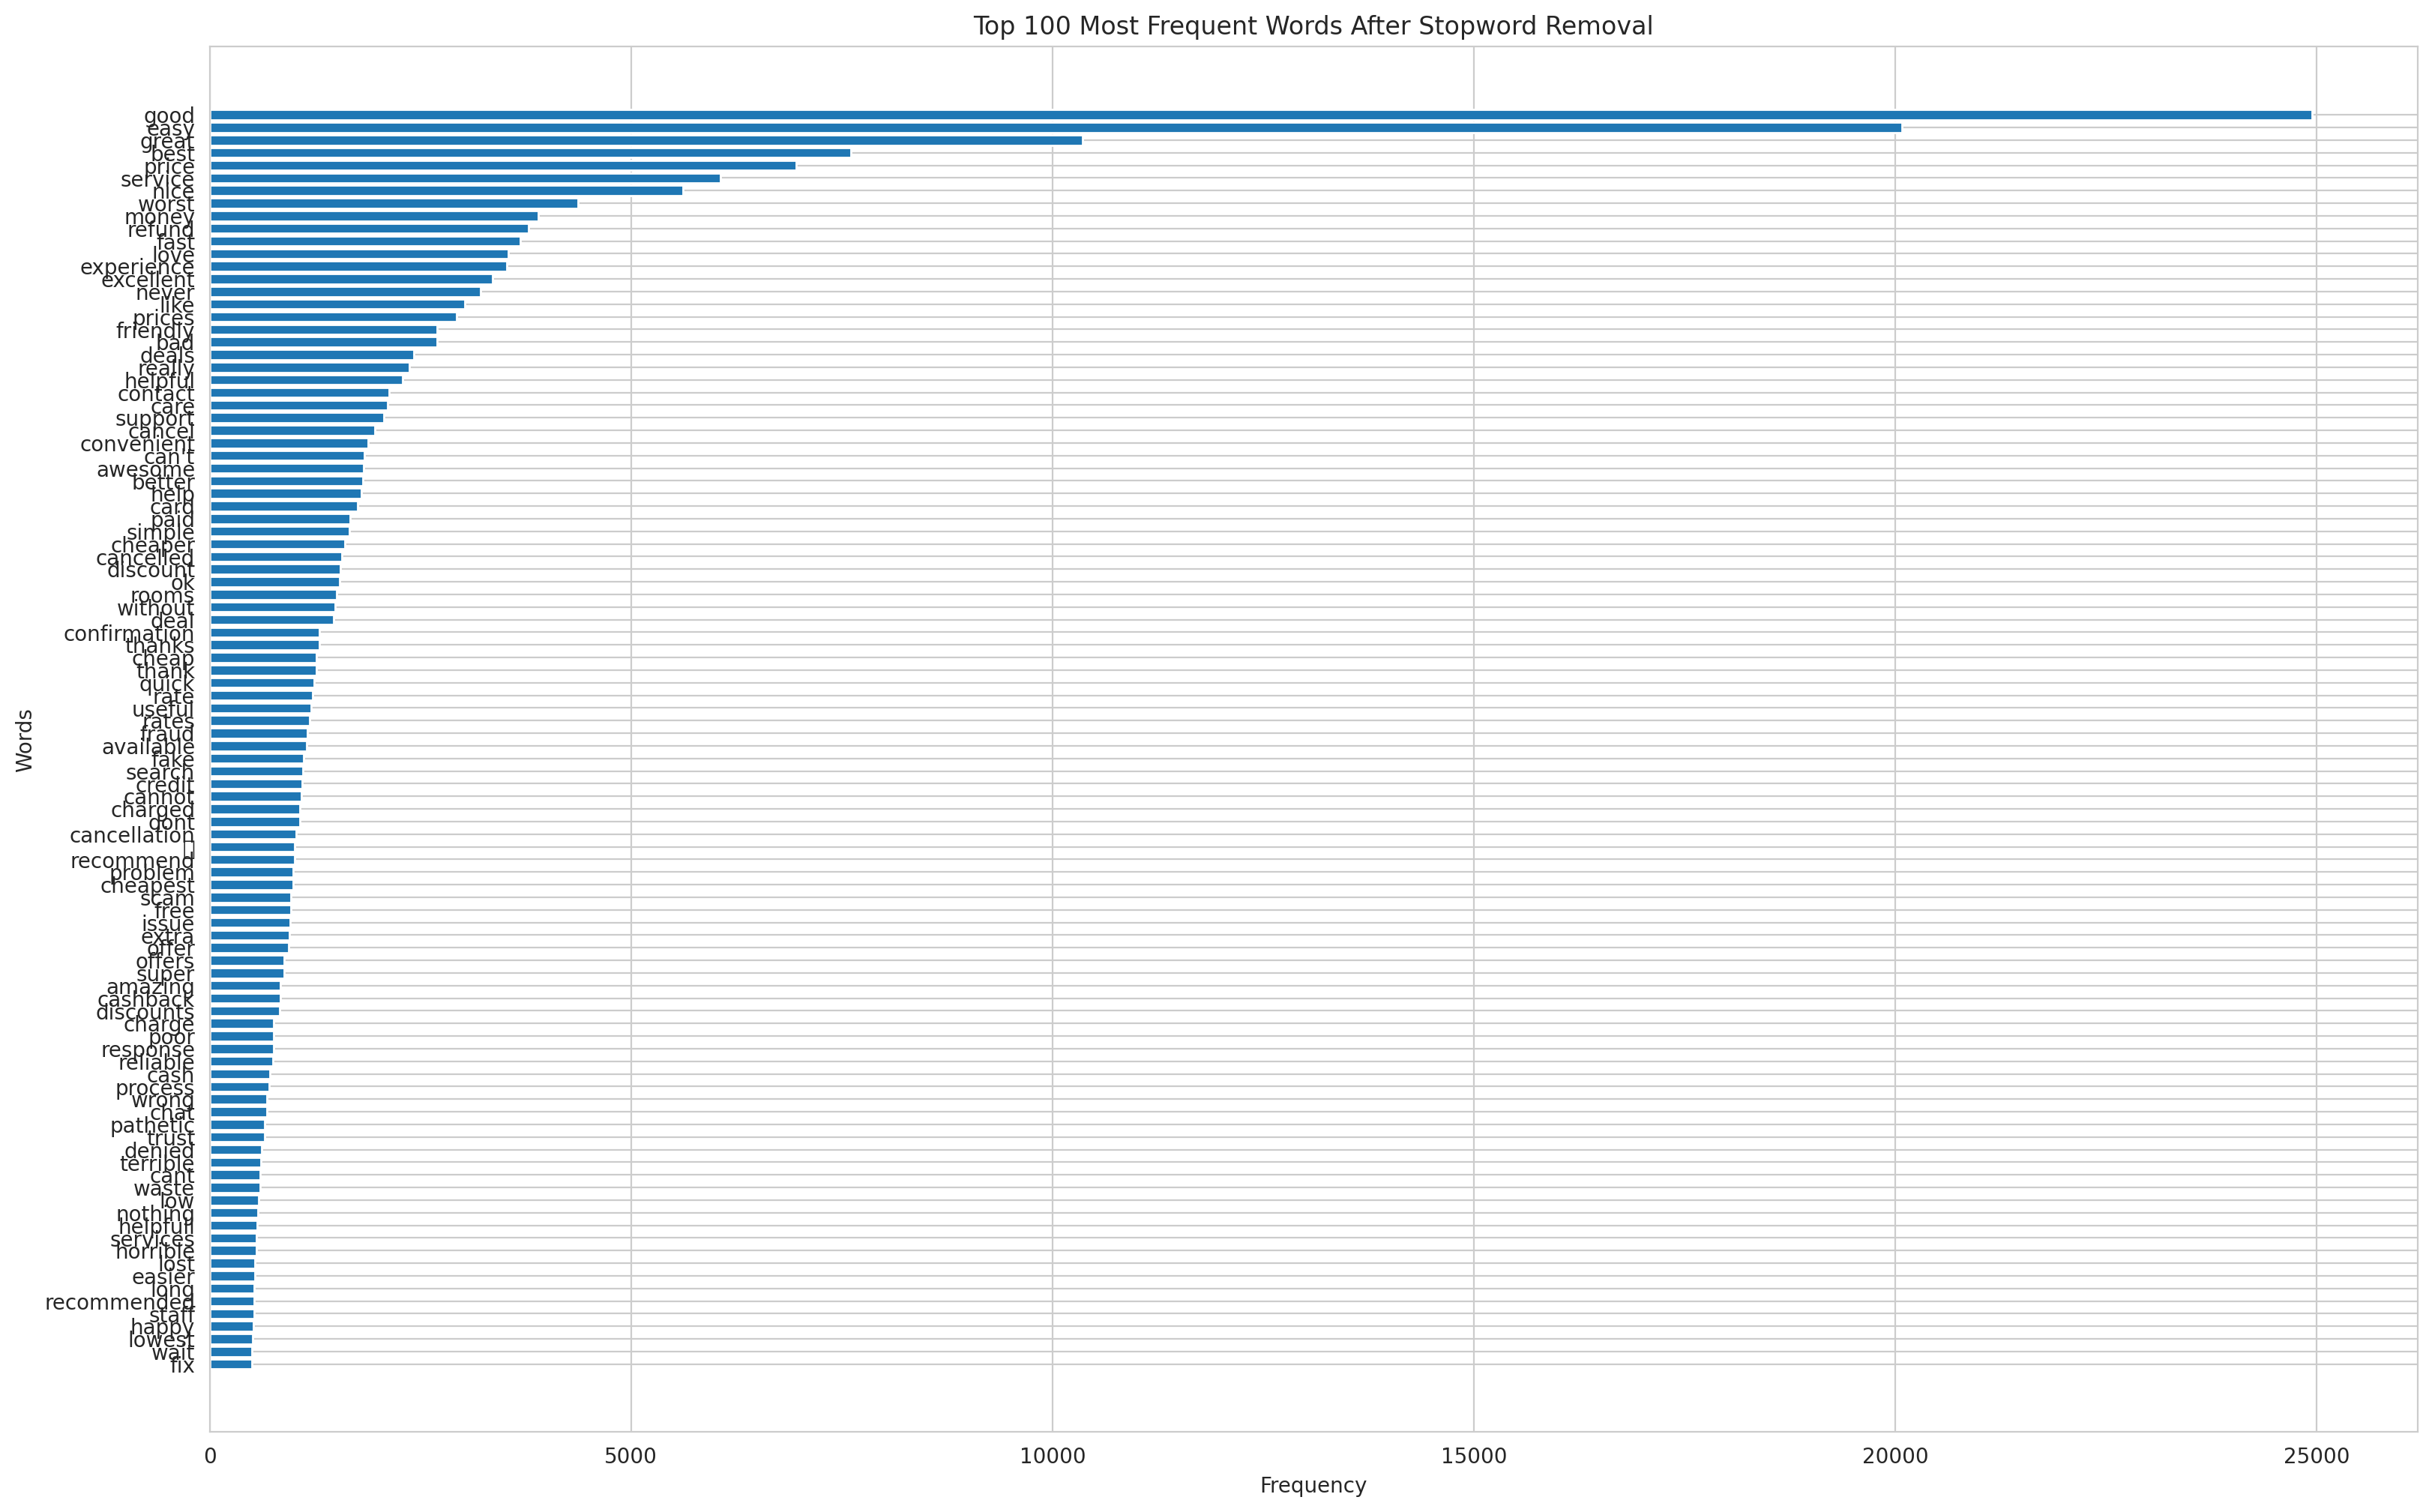

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Kolom teks
text_column = 'content'

# Gabungkan semua teks
all_text = ' '.join(df_agodarev[text_column].dropna().astype(str))

# Tokenisasi
words = all_text.split()

# Hapus stopwords (termasuk custom yang sudah kamu tambahkan)
filtered_words = [word.lower() for word in words if word.lower() not in english_stopwords]

# Hitung frekuensi kata lagi
word_counts = Counter(filtered_words)

# Ambil 100 kata paling sering setelah stopwords baru
common_words_clean = word_counts.most_common(100)

# Convert ke DataFrame
word_freq_df_clean = pd.DataFrame(common_words_clean, columns=['Word', 'Frequency'])

# Print hasil
print(common_words_clean)

# Tampilkan tabel
display(word_freq_df_clean)

# Plot grafik
plt.figure(figsize=(19,12))
plt.barh(word_freq_df_clean['Word'][::-1], word_freq_df_clean['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 100 Most Frequent Words After Stopword Removal")
plt.show()